# When Constant Arrays Produce Non-Zero Standard Deviations — Part I

Consider a vector of $N$ data points in which every stored value is identical—for example, $[1.81, 1.81, \ldots, 1.81]$. This could be a constant NumPy array or a constant pandas Series. Let $\mathbf{x}$ denote the vector and $c$ the shared value.
$$
\mathbf{x} =
\begin{bmatrix}
c \\
c \\
\vdots \\
c
\end{bmatrix}
\in \mathbb{R}^N
$$

In exact arithmetic,
$$
x_i = c \qquad \forall i \in \{0,\ldots,N-1\}
$$
so every element from $x_0$ to $x_{N-1}$ equals $c$. Consequently, the mean $\bar{x}$ equals $c$ and the standard deviation $s_x$ equals $0$.

Floating-point reductions are not exact, however. Even when all stored elements are bitwise identical, rounding during the mean calculation can move the computed mean by one or more ULPs. Centering the values around that rounded mean can then produce a non-zero computed standard deviation.

These effects are tiny—typically on the order of machine precision—but they can influence downstream calculations such as Pearson correlation (explored in the following notebooks). They depend on the value, dtype, array size, and reduction algorithm. In the float32 examples below, NumPy and pandas also produce different standard deviations. <br>

For reproducibility, the pandas comparisons use the native pandas implementation; optional Bottleneck acceleration is disabled.



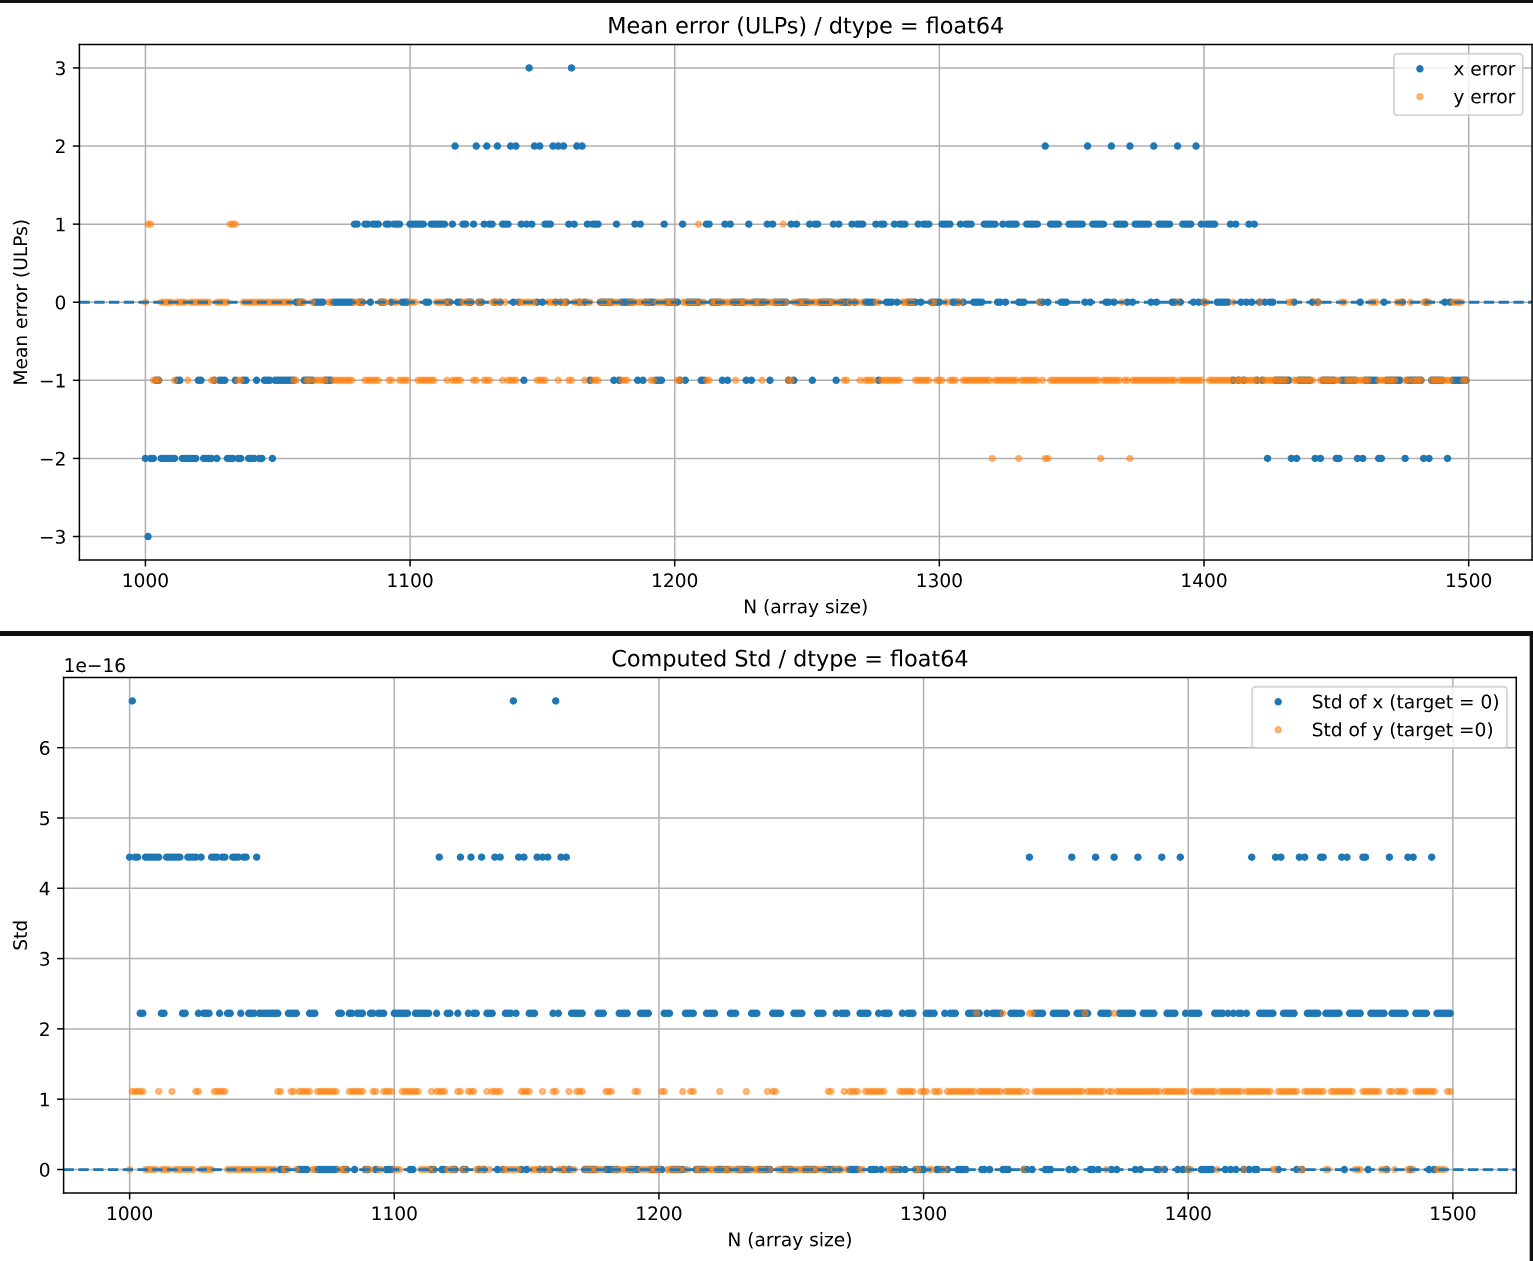
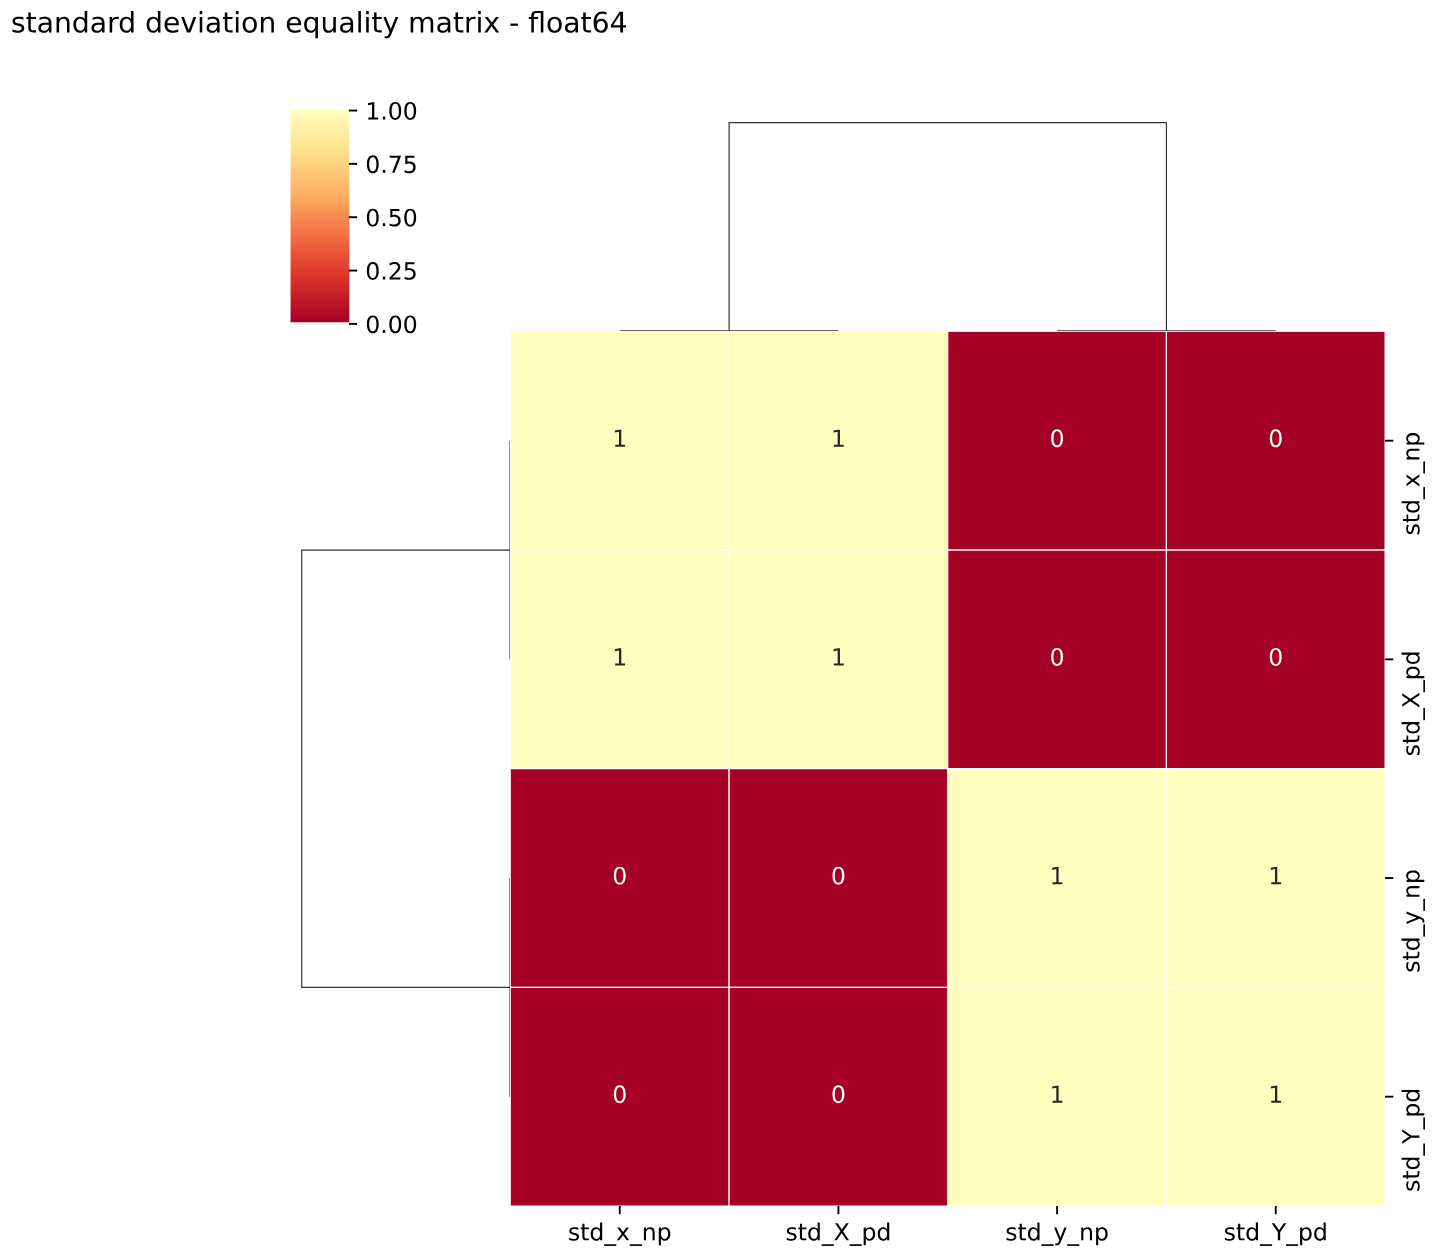

## Minimal Reproducible Example

In [1]:
import numpy as np
import pandas as pd
pd.set_option("compute.use_bottleneck", False)
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline as inline
inline.set_matplotlib_formats('svg')


print('Numpy version:',np.__version__)
print('Pandas version:',pd.__version__)

def print_mean_and_std(label, values):
    stored_value = values[0]
    mean = values.mean()
    std = values.std(ddof=1)

    print(f"Stored value of {label}: {stored_value!r}")
    print(f"Mean of {label}: {mean}")
    print(f"Mean error from stored value: {mean - stored_value}")
    print(f"Sample standard deviation of {label} (ddof=1): {std}")

Numpy version: 2.5.2
Pandas version: 3.0.5


In [2]:
def report_std(dtype, n):
    print(f'\n{dtype.__name__}, N = {n}')
    print('-' * 40)

    for name, value in {'x': 1.810, 'y': 0.576}.items():
        array = np.repeat(dtype(value), n)
        series = pd.Series(array)

        # Every element has exactly the same stored floating-point value.
        assert np.unique(array).size == 1

        print(f'{name}: unique values = {np.unique(array)}')
        print(f'  mean = {array.mean()}')
        print(f'  mean error from stored value: {array.mean() - array[0]:.20g}')
        print(f'  NumPy std (ddof=1):  {array.std(ddof=1):.20g}')
        print(f'  pandas std (ddof=1): {series.std(ddof=1):.20g}')


In [3]:
for dtype in (np.float64, np.float32):
    for n in (1448, 1372):
        report_std(dtype, n)


float64, N = 1448
----------------------------------------
x: unique values = [1.81]
  mean = 1.8099999999999998
  mean error from stored value: -2.2204460492503130808e-16
  NumPy std (ddof=1):  2.2212131752186999292e-16
  pandas std (ddof=1): 2.2212131752186999292e-16
y: unique values = [0.576]
  mean = 0.5759999999999998
  mean error from stored value: -1.1102230246251565404e-16
  NumPy std (ddof=1):  1.1106065876093499646e-16
  pandas std (ddof=1): 1.1106065876093499646e-16

float64, N = 1372
----------------------------------------
x: unique values = [1.81]
  mean = 1.8100000000000005
  mean error from stored value: 4.4408920985006261617e-16
  NumPy std (ddof=1):  4.4425113846432276256e-16
  pandas std (ddof=1): 4.4425113846432276256e-16
y: unique values = [0.576]
  mean = 0.5759999999999997
  mean error from stored value: -2.2204460492503130808e-16
  NumPy std (ddof=1):  2.2212556923216138128e-16
  pandas std (ddof=1): 2.2212556923216138128e-16

float32, N = 1448
----------------

For the examples above, the computed mean can differ from the stored value and the computed standard deviation can be non-zero. pandas returns zero for the float32 standard deviations in this specific case.

## Detailed Analysis

In [4]:
# Find the ULP (unit in the last place) distance between two values.

def find_ulp(data1, data2, limit = 20):
    counter = 0
    
    if data1 > data2:
        if isinstance(data1, np.float64):
            while np.float64(data1).view(np.uint64) != np.float64(data2).view(np.uint64):
                data2 = np.nextafter(data2, np.inf)                
                if counter >= limit:
                    print(f"Counter limit of {limit} reached before a matching value was found.")
                    break
                counter += 1
            else:
                print(f"data1 > data2. ULP distance: {counter}")

        elif isinstance(data1, np.float32):
            while np.float32(data1).view(np.uint32) != np.float32(data2).view(np.uint32):
                data2 = np.nextafter(data2, np.inf)
                if counter >= limit:
                    print(f"Counter limit of {limit} reached before a matching value was found.")
                    break
                counter += 1
            else:
                print(f"data1 > data2. ULP distance: {counter}")

        else:
            print("Use np.float64 or np.float32 values.")

    elif data1 < data2:
        if isinstance(data1, np.float64):
            while np.float64(data1).view(np.uint64) != np.float64(data2).view(np.uint64):
                data2 = np.nextafter(data2, -np.inf)
                if counter >= limit:
                    print(f"Counter limit of {limit} reached before a matching value was found.")
                    break
                counter += 1  
            else:
                print(f"data1 < data2. ULP distance: {counter}")

        elif isinstance(data1, np.float32):
            while np.float32(data1).view(np.uint32) != np.float32(data2).view(np.uint32):
                data2 = np.nextafter(data2, -np.inf)
                if counter >= limit:
                    print(f"Counter limit of {limit} reached before a matching value was found.")
                    break
                counter += 1
            else:
                print(f"data1 < data2. ULP distance: {counter}")

        else:
            print("Use np.float64 or np.float32 values.")

    else:
        print('data1 and data2 are identical. ULP distance: 0')
        

ULP (Unit in the Last Place): the smallest difference between two adjacent floating-point numbers at a given magnitude.

## 1. float64

### 1.1 NumPy

In [5]:
# Create float64 arrays with 1,448 elements.
N = 1448

x = np.repeat(1.810, N)
y = np.repeat(0.576, N)

# Equivalent construction:
# x = np.full(1448, 1.810)
# y = np.full(1448, 0.576)


In [6]:
print(x.shape)
print(np.unique(x))
print(y.shape)
print(np.unique(y))

(1448,)
[1.81]
(1448,)
[0.576]


In exact arithmetic, the means are 1.810 and 0.576, and both standard deviations are zero.

In [7]:
# Calculate the mean and sample standard deviation.

print('-' * 40)
print_mean_and_std('x', x)
print()
print_mean_and_std('y', y)
print('-' * 40)



----------------------------------------
Stored value of x: np.float64(1.81)
Mean of x: 1.8099999999999998
Mean error from stored value: -2.220446049250313e-16
Sample standard deviation of x (ddof=1): 2.2212131752187e-16

Stored value of y: np.float64(0.576)
Mean of y: 0.5759999999999998
Mean error from stored value: -1.1102230246251565e-16
Sample standard deviation of y (ddof=1): 1.11060658760935e-16
----------------------------------------


The results show rounding in the computed means of these constant arrays.

The next cell measures the difference in ULPs (units in the last place).

In [8]:
ulp_x = find_ulp(x[0],np.mean(x))
ulp_y = find_ulp(y[0],np.mean(y))

data1 > data2. ULP distance: 1
data1 > data2. ULP distance: 1


For $N = 1448$, both stored values are one ULP above their computed means.

The result varies with the number of elements because the reduction accumulates rounding differently as $N$ changes.

The example below demonstrates the behavior:

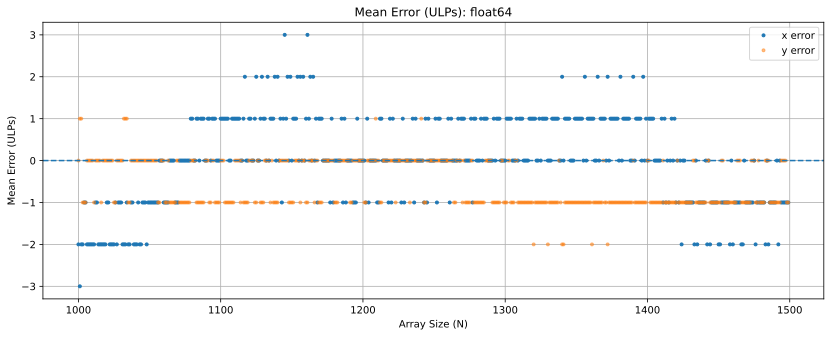

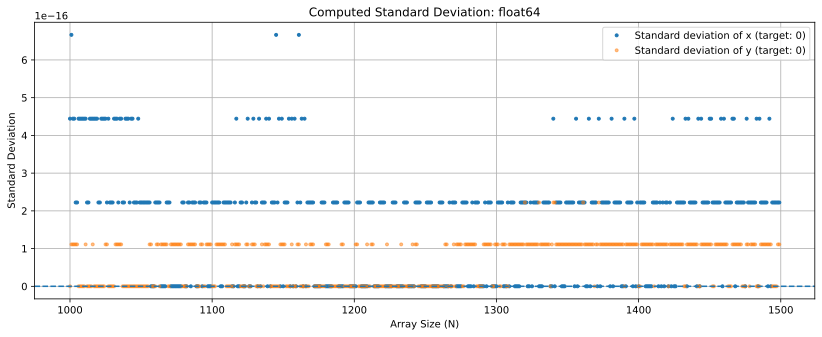

In [9]:
xv = 1.810
yv = 0.576

Ns = np.arange(1000, 1500)
stds_x = []
stds_y = []
means_x = []
means_y = []

for N in Ns:
    x = np.repeat(xv, N)
    y = np.repeat(yv, N)
    stds_x.append(np.std(x, ddof=1))
    stds_y.append(np.std(y, ddof=1))
    means_x.append(np.mean(x))
    means_y.append(np.mean(y))

stds_x = np.asarray(stds_x)
stds_y = np.asarray(stds_y)

means_x = np.asarray(means_x)
means_y = np.asarray(means_y)

error_x = (means_x - xv) / np.spacing(xv)
error_y = (means_y - yv) / np.spacing(yv)


plt.figure(figsize=(14, 5))

plt.title("Mean Error (ULPs): float64")
plt.plot(Ns, error_x, '.', label='x error')
plt.plot(Ns, error_y, '.', label='y error', alpha=0.5)
plt.axhline(0, linestyle='--')
plt.xlabel("Array Size (N)")
plt.ylabel("Mean Error (ULPs)")
plt.legend(draggable=True)
plt.grid(True)
plt.show()

plt.figure(figsize=(14,5))

plt.title("Computed Standard Deviation: float64")
plt.plot(Ns, stds_x, ".")
plt.plot(Ns, stds_y, ".", alpha = 0.5)
plt.axhline(0, linestyle='--')
plt.xlabel("Array Size (N)")
plt.ylabel("Standard Deviation")
plt.legend(['Standard deviation of x (target: 0)', 'Standard deviation of y (target: 0)'], draggable=True)
plt.grid(True)
plt.show()

### 1.2 pandas

In exact arithmetic, the means are 1.810 and 0.576, and both standard deviations are zero.

In [10]:
# Re-create the 1,448-element float64 arrays and convert them to pandas Series.

N = 1448
x = np.repeat(1.810, N)
y = np.repeat(0.576, N)

X = pd.Series(x)
Y = pd.Series(y)

In [11]:
# Calculate the mean and sample standard deviation.

print('-' * 40)
print_mean_and_std('X', X)
print()
print_mean_and_std('Y', Y)
print('-' * 40)



----------------------------------------
Stored value of X: np.float64(1.81)
Mean of X: 1.8099999999999998
Mean error from stored value: -2.220446049250313e-16
Sample standard deviation of X (ddof=1): 2.2212131752187e-16

Stored value of Y: np.float64(0.576)
Mean of Y: 0.5759999999999998
Mean error from stored value: -1.1102230246251565e-16
Sample standard deviation of Y (ddof=1): 1.11060658760935e-16
----------------------------------------


The computed values contain the same rounding effects.

Do they match the NumPy results?

In [12]:
print(f"NumPy mean of x == pandas mean of X: {x.mean() == X.mean()}")
print(f"NumPy standard deviation of x == pandas standard deviation of X: {x.std(ddof=1) == X.std()}")
print('-' * 40)
print(f"NumPy mean of y == pandas mean of Y: {y.mean() == Y.mean()}")
print(f"NumPy standard deviation of y == pandas standard deviation of Y: {y.std(ddof=1) == Y.std()}")

NumPy mean of x == pandas mean of X: True
NumPy standard deviation of x == pandas standard deviation of X: True
----------------------------------------
NumPy mean of y == pandas mean of Y: True
NumPy standard deviation of y == pandas standard deviation of Y: True


For float64, NumPy and pandas produce the same results in this example, so the corresponding pandas plots would match the NumPy plots in Section 1.1.

## 2. float32

Repeat the experiment using the float32 dtype.

In [13]:
# Create float32 arrays with 1,448 elements.
N = 1448

x = np.repeat(np.float32(1.810), N)
y = np.repeat(np.float32(0.576), N)

In [14]:
print(x.shape)
print(np.unique(x))
print(y.shape)
print(np.unique(y))

(1448,)
[1.81]
(1448,)
[0.576]


### 2.1 NumPy

In exact arithmetic, the means are 1.810 and 0.576, and both standard deviations are zero.

In [15]:
# Calculate the mean and sample standard deviation.

print('-' * 40)
print_mean_and_std('x', x)
print()
print_mean_and_std('y', y)
print('-' * 40)

----------------------------------------
Stored value of x: np.float32(1.81)
Mean of x: 1.8099995851516724
Mean error from stored value: -3.5762786865234375e-07
Sample standard deviation of x (ddof=1): 3.577514178232377e-07

Stored value of y: np.float32(0.576)
Mean of y: 0.5760000944137573
Mean error from stored value: 1.1920928955078125e-07
Sample standard deviation of y (ddof=1): 1.192504726077459e-07
----------------------------------------


The float32 results show larger rounding effects than the float64 results.

The next cell measures the difference in ULPs (units in the last place).

In [16]:
ulp_x = find_ulp(x[0],np.mean(x))
ulp_y = find_ulp(y[0],np.mean(y))

data1 > data2. ULP distance: 3
data1 < data2. ULP distance: 2


For $N = 1448$, the stored value 1.81 is three ULPs above its computed mean, while 0.576 is two ULPs below its computed mean.

As with float64, the result varies with the number of elements because the reduction accumulates rounding differently as $N$ changes.

The example below demonstrates the behavior:

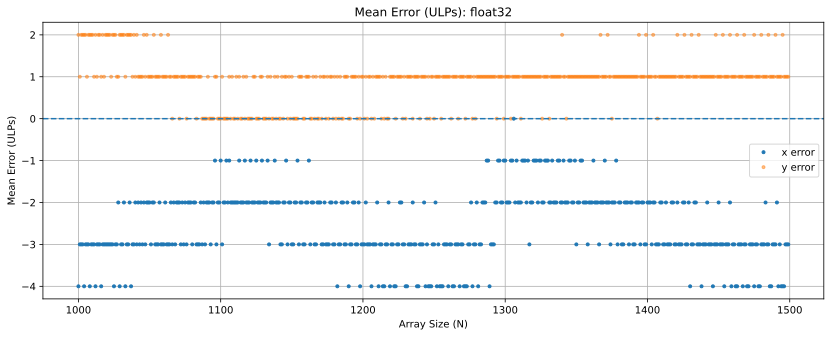

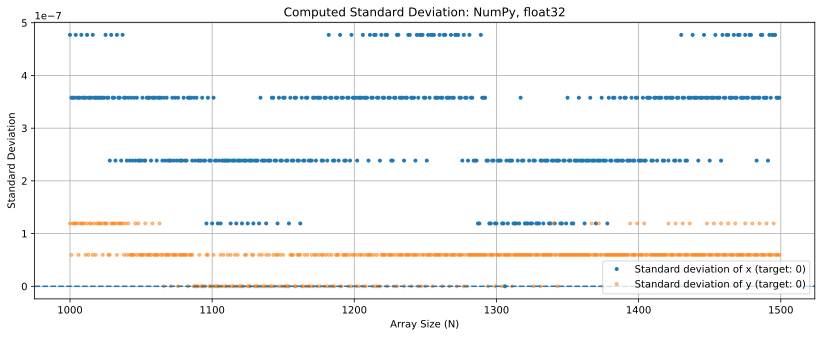

In [17]:
xv = np.float32(1.810)
yv = np.float32(0.576)

Ns = np.arange(1000, 1500)
stds_x = []
stds_y = []
means_x = []
means_y = []

for N in Ns:
    x = np.repeat(xv, N)
    y = np.repeat(yv, N)
    stds_x.append(np.std(x, ddof=1))
    stds_y.append(np.std(y, ddof=1))
    means_x.append(np.mean(x))
    means_y.append(np.mean(y))

stds_x = np.asarray(stds_x)
stds_y = np.asarray(stds_y)

means_x = np.asarray(means_x)
means_y = np.asarray(means_y)

error_x = (means_x - xv) / np.spacing(xv)
error_y = (means_y - yv) / np.spacing(yv)


plt.figure(figsize=(14, 5))

plt.title("Mean Error (ULPs): float32")
plt.plot(Ns, error_x, '.', label='x error')
plt.plot(Ns, error_y, '.', label='y error', alpha=0.5)
plt.axhline(0, linestyle='--')
plt.xlabel("Array Size (N)")
plt.ylabel("Mean Error (ULPs)")
plt.legend(draggable=True)
plt.grid(True)
plt.show()

plt.figure(figsize=(14,5))

plt.title("Computed Standard Deviation: NumPy, float32")
plt.plot(Ns, stds_x, ".")
plt.plot(Ns, stds_y, ".", alpha = 0.5)
plt.axhline(0, linestyle='--')
plt.xlabel("Array Size (N)")
plt.ylabel("Standard Deviation")
plt.legend(['Standard deviation of x (target: 0)', 'Standard deviation of y (target: 0)'], draggable=True)
plt.grid(True)
plt.show()

### 2.2 pandas

In exact arithmetic, the means are 1.810 and 0.576, and both standard deviations are zero.

In [18]:
# Re-create the 1,448-element float32 arrays before converting them to pandas Series.
N = 1448
x = np.repeat(np.float32(1.810), N)
y = np.repeat(np.float32(0.576), N)

X = pd.Series(x)
Y = pd.Series(y)

In [19]:
# Calculate the mean and sample standard deviation.

print('-' * 40)
print_mean_and_std('X', X)
print()
print_mean_and_std('Y', Y)
print('-' * 40)

----------------------------------------
Stored value of X: np.float32(1.81)
Mean of X: 1.8099995851516724
Mean error from stored value: -3.5762786865234375e-07
Sample standard deviation of X (ddof=1): 0.0

Stored value of Y: np.float32(0.576)
Mean of Y: 0.5760000944137573
Mean error from stored value: 1.1920928955078125e-07
Sample standard deviation of Y (ddof=1): 0.0
----------------------------------------


The computed means show the same rounding effects.

Do the results match the NumPy results?

In [20]:
print(f"NumPy mean of x == pandas mean of X: {x.mean() == X.mean()}")
print(f"NumPy standard deviation of x == pandas standard deviation of X: {x.std(ddof=1) == X.std()}")
print('-' * 40)
print(f"NumPy mean of y == pandas mean of Y: {y.mean() == Y.mean()}")
print(f"NumPy standard deviation of y == pandas standard deviation of Y: {y.std(ddof=1) == Y.std()}")

NumPy mean of x == pandas mean of X: True
NumPy standard deviation of x == pandas standard deviation of X: False
----------------------------------------
NumPy mean of y == pandas mean of Y: True
NumPy standard deviation of y == pandas standard deviation of Y: False


For this float32 example, the means match, but the standard deviations differ: pandas returns exactly zero.

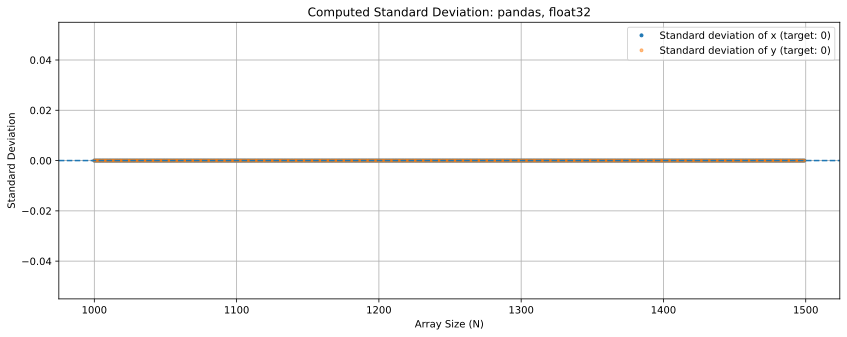

In [21]:
xv = np.float32(1.810)
yv = np.float32(0.576)

Ns = np.arange(1000, 1500)
stds_x = []
stds_y = []
means_x = []
means_y = []

for N in Ns:
    x = pd.Series(np.repeat(xv, N))
    y = pd.Series(np.repeat(yv, N))
    stds_x.append(np.std(x, ddof=1))
    stds_y.append(np.std(y, ddof=1))
    means_x.append(np.mean(x))
    means_y.append(np.mean(y))

stds_x = np.asarray(stds_x)
stds_y = np.asarray(stds_y)

plt.figure(figsize=(14,5))

plt.title("Computed Standard Deviation: pandas, float32")
plt.plot(Ns, stds_x, ".")
plt.plot(Ns, stds_y, ".", alpha = 0.5)
plt.axhline(0, linestyle='--')
plt.xlabel("Array Size (N)")
plt.ylabel("Standard Deviation")
plt.legend(['Standard deviation of x (target: 0)', 'Standard deviation of y (target: 0)'], draggable=True)
plt.grid(True)
plt.show()

This is a meaningful implementation difference: for these float32 inputs, pandas returns the mathematical result of zero while NumPy returns a small non-zero value. For float64, NumPy and pandas return the same rounded results in this example.

# 3. Summary and Visualization

In [22]:
results = []
for N in range(1000, 1501,1):
    for dtype in [np.float64, np.float32]:
        x = np.repeat(dtype(1.81), N)
        y = np.repeat(dtype(0.576), N)
        
        X = pd.Series(x)
        Y = pd.Series(y)
        
        results.append({
            "N": N,
            "dtype": dtype,
            "mean_err_x (ULP)": (np.mean(x) - x[0]) /  np.spacing(x[0]),
            "mean_err_y (ULP)": (np.mean(y) - y[0]) / np.spacing(y[0]),
            "std_x_np": np.std(x, ddof=1),
            "std_X_pd": X.std(ddof = 1),
            "std_y_np": np.std(y, ddof=1),
            "std_Y_pd": Y.std(ddof = 1),

        })
        
results = pd.DataFrame(results)   

The table below summarizes the results across all array sizes and dtypes.

In [23]:
results

,N,dtype,mean_err_x (ULP),mean_err_y (ULP),std_x_np,std_X_pd,std_y_np,std_Y_pd
0,1000,<class 'numpy.float64'>,-2.0,0.0,4.443114e-16,4.443114e-16,0.000000e+00,0.000000e+00
1,1000,<class 'numpy.float32'>,-4.0,2.0,4.770757e-07,0.000000e+00,1.192689e-07,0.000000e+00
2,1001,<class 'numpy.float64'>,-3.0,1.0,6.664668e-16,6.664668e-16,1.110778e-16,1.110778e-16
3,1001,<class 'numpy.float32'>,-3.0,1.0,3.578066e-07,0.000000e+00,5.963444e-08,0.000000e+00
4,1002,<class 'numpy.float64'>,-2.0,1.0,4.443110e-16,4.443110e-16,1.110777e-16,1.110777e-16
...,...,...,...,...,...,...,...,...
997,1498,<class 'numpy.float32'>,-3.0,1.0,3.577473e-07,0.000000e+00,5.962455e-08,0.000000e+00
998,1499,<class 'numpy.float64'>,-1.0,-1.0,2.221187e-16,2.221187e-16,1.110594e-16,1.110594e-16
999,1499,<class 'numpy.float32'>,-3.0,1.0,3.577472e-07,0.000000e+00,5.962454e-08,0.000000e+00
1000,1500,<class 'numpy.float64'>,0.0,-1.0,0.000000e+00,0.000000e+00,1.110593e-16,1.110593e-16


The following table isolates $N = 1448$, the main example in this investigation.

In [24]:
results.loc[results['N'] == 1448]

,N,dtype,mean_err_x (ULP),mean_err_y (ULP),std_x_np,std_X_pd,std_y_np,std_Y_pd
896,1448,<class 'numpy.float64'>,-1.0,-1.0,2.221213e-16,2.221213e-16,1.110607e-16,1.110607e-16
897,1448,<class 'numpy.float32'>,-3.0,2.0,3.577514e-07,0.000000e+00,1.192505e-07,0.000000e+00


Split the results into float32 and float64 subsets for further analysis.

In [25]:
results_F64 = results.iloc[np.where(results['dtype'] ==  np.float64)]
results_F64.describe()

,N,mean_err_x (ULP),mean_err_y (ULP),std_x_np,std_X_pd,std_y_np,std_Y_pd
count,501.000000,501.000000,501.000000,5.010000e+02,5.010000e+02,5.010000e+02,5.010000e+02
mean,1250.000000,-0.025948,-0.548902,1.760240e-16,1.760240e-16,6.406785e-17,6.406785e-17
std,144.770508,1.045622,0.547817,1.514500e-16,1.514500e-16,5.755969e-17,5.755969e-17
min,1000.000000,-3.000000,-2.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1125.000000,-1.000000,-1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1250.000000,0.000000,-1.000000,2.221252e-16,2.221252e-16,1.110605e-16,1.110605e-16
75%,1375.000000,1.000000,0.000000,2.221442e-16,2.221442e-16,1.110647e-16,1.110647e-16
max,1500.000000,3.000000,1.000000,6.664668e-16,6.664668e-16,2.221288e-16,2.221288e-16


In [26]:
results_F32 = results.iloc[np.where(results['dtype'] ==  np.float32)]
results_F32.describe()

,N,mean_err_x (ULP),mean_err_y (ULP),std_x_np,std_X_pd,std_y_np,std_Y_pd
count,501.000000,501.000000,501.000000,5.010000e+02,501.0,5.010000e+02,501.0
mean,1250.000000,-2.558882,0.914172,3.051662e-07,0.0,5.451092e-08,0.0
std,144.770508,0.831280,0.550108,9.913553e-08,0.0,3.280301e-08,0.0
min,1000.000000,-4.000000,0.000000,0.000000e+00,0.0,0.000000e+00,0.0
25%,1125.000000,-3.000000,1.000000,2.385103e-07,0.0,5.962497e-08,0.0
50%,1250.000000,-3.000000,1.000000,3.577497e-07,0.0,5.962718e-08,0.0
75%,1375.000000,-2.000000,1.000000,3.577823e-07,0.0,5.963062e-08,0.0
max,1500.000000,0.000000,2.000000,4.770757e-07,0.0,1.192689e-07,0.0


## 3.1 Mean-error distribution: float64

The following box plots summarize the distributions.

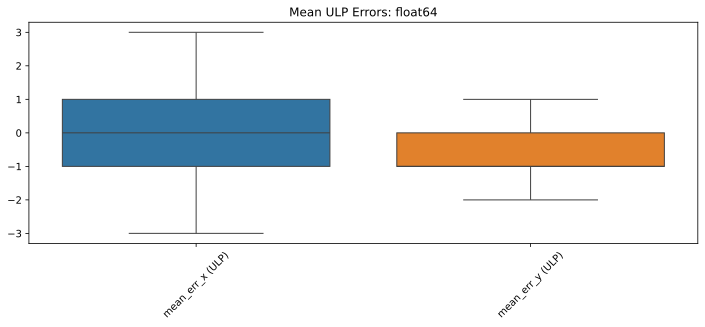

In [27]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=results_F64.iloc[:, 2:4], ax=ax)
ax.tick_params(axis='x', labelrotation=45)
ax.set_title('Mean ULP Errors: float64')
plt.show()

The following histogram shows the same distribution:

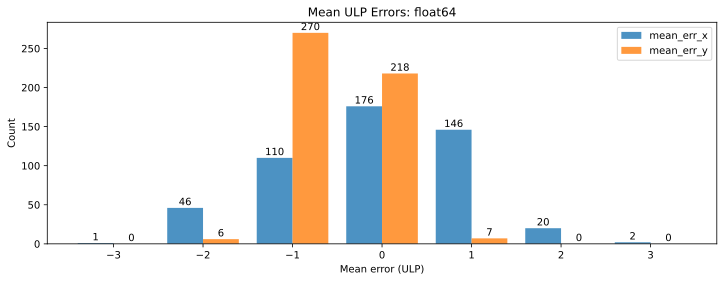

In [28]:
Max = results_F64.loc[:,['mean_err_x (ULP)','mean_err_y (ULP)']].to_numpy().max()
Min = results_F64.loc[:,['mean_err_x (ULP)','mean_err_y (ULP)']].to_numpy().min()

x = results_F64['mean_err_x (ULP)']
y = results_F64['mean_err_y (ULP)']

edges = np.arange(Min - 0.5, Max + 1.5, 1)
centers = (edges[1:] + edges[:-1]) / 2

hist_x, _ = np.histogram(x, bins=edges)
hist_y, _ = np.histogram(y, bins=edges)

fig, ax = plt.subplots(figsize=(12, 4))

width = 0.4

ax.bar(centers - width/2, hist_x, width=width,
       label='mean_err_x', alpha=0.8)

ax.bar(centers + width/2, hist_y, width=width,
       label='mean_err_y', alpha=0.8)

ax.set_title('Mean ULP Errors: float64')
ax.set_xticks(centers)
ax.set_xlabel('Mean error (ULP)')
ax.set_ylabel('Count')
ax.legend()

# Labels
for i, x_val in enumerate(centers):
    ax.text(x_val - width/2, hist_x[i] + 0.5, int(hist_x[i]),
            ha='center', va='bottom')
    ax.text(x_val + width/2, hist_y[i] + 0.5, int(hist_y[i]),
            ha='center', va='bottom')

plt.show()

## 3.2 Standard-deviation distribution: float64

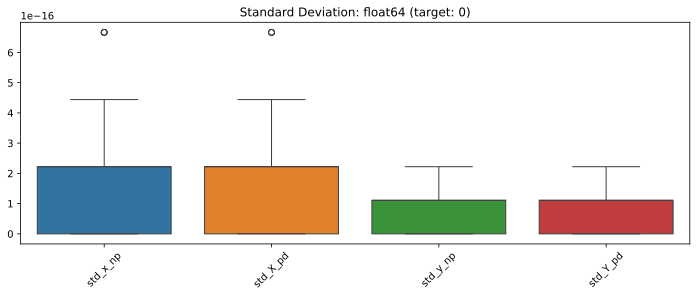

In [29]:
fig,ax = plt.subplots(1,figsize=(12,4))
ax = sns.boxplot(data = results_F64.iloc[:,4:], ax=ax)
ax.tick_params(axis='x', labelrotation=45)
plt.title('Standard Deviation: float64 (target: 0)')
plt.show()

For float64, NumPy and pandas produce identical standard deviations for both values in this sweep. The following histogram therefore uses only the NumPy results.

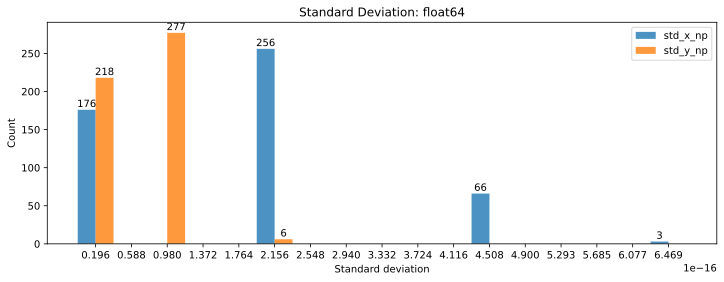

In [30]:
n_bins = 17

x = results_F64['std_x_np'].to_numpy()
y = results_F64['std_y_np'].to_numpy()

Min = min(x.min(), y.min())
Max = max(x.max(), y.max())

edges = np.linspace(Min,Max,n_bins + 1)


hist_x, _ = np.histogram(x, bins=edges)
hist_y, _ = np.histogram(y, bins=edges)

centers = (edges[:-1] + edges[1:]) / 2
width = edges[1] - edges[0]

fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(
    centers - width/4,
    hist_x,
    width=width/2,
    label='std_x_np',
    alpha=0.8
)

ax.bar(
    centers + width/4,
    hist_y,
    width=width/2,
    label='std_y_np',
    alpha=0.8
)

ax.set_title('Standard Deviation: float64')
ax.set_xlabel('Standard deviation')
ax.set_ylabel('Count')

ax.set_xticks(centers)
ax.legend()


for i, x_val in enumerate(centers):
        if hist_x[i] > 0:
            ax.text(x_val - width/4, hist_x[i] + 0.5, int(hist_x[i]),
                    ha='center', va='bottom')
            
        if hist_y[i] > 0:
            ax.text(x_val + width/4, hist_y[i] + 0.5, int(hist_y[i]),
                ha='center', va='bottom')

plt.show()


The next two cells count the exact zero standard deviations in the float64 results.

In [31]:
len(np.where(results_F64['std_x_np'] == 0)[0])

176

In [32]:
len(np.where(results_F64['std_y_np'] == 0)[0])

218

## 3.3 Mean-error distribution: float32

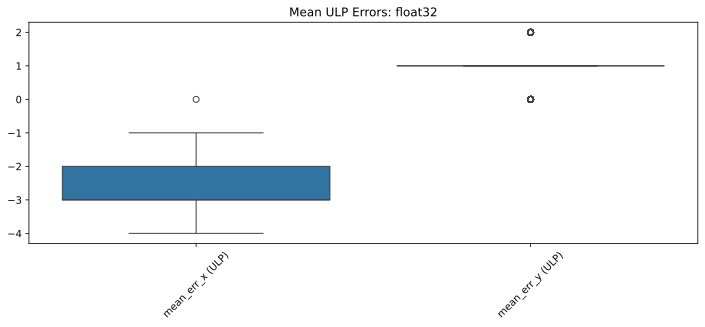

In [33]:
fig,ax = plt.subplots(1,figsize=(12,4))
ax = sns.boxplot(data = results_F32.iloc[:,2:4])
ax.tick_params(axis='x', labelrotation=45)
plt.title('Mean ULP Errors: float32')
plt.show()

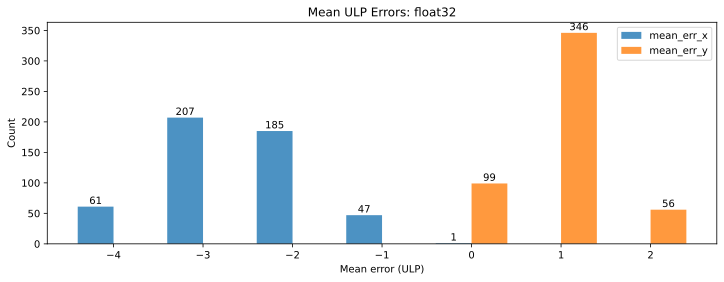

In [34]:
Max = results_F32.loc[:,['mean_err_x (ULP)','mean_err_y (ULP)']].to_numpy().max()
Min = results_F32.loc[:,['mean_err_x (ULP)','mean_err_y (ULP)']].to_numpy().min()

x = results_F32['mean_err_x (ULP)']
y = results_F32['mean_err_y (ULP)']

edges = np.arange(Min - 0.5, Max + 1.5, 1)
centers = (edges[1:] + edges[:-1]) / 2

hist_x, _ = np.histogram(x, bins=edges)
hist_y, _ = np.histogram(y, bins=edges)

fig, ax = plt.subplots(figsize=(12, 4))

width = 0.4

ax.bar(centers - width/2, hist_x, width=width,
       label='mean_err_x', alpha=0.8)

ax.bar(centers + width/2, hist_y, width=width,
       label='mean_err_y', alpha=0.8)

ax.set_title('Mean ULP Errors: float32')
ax.set_xticks(centers)
ax.set_xlabel('Mean error (ULP)')
ax.set_ylabel('Count')
ax.legend()

for i, x_val in enumerate(centers):
    if hist_x[i] > 0:
        ax.text(x_val - width/2, hist_x[i] + 0.5, int(hist_x[i]),
            ha='center', va='bottom')
    if hist_y[i] > 0:
        ax.text(x_val + width/2, hist_y[i] + 0.5, int(hist_y[i]),
            ha='center', va='bottom')

plt.show()

Across this sweep, the ULP error for x is non-positive, while the ULP error for y is non-negative.

## 3.4 Standard-deviation distribution: float32

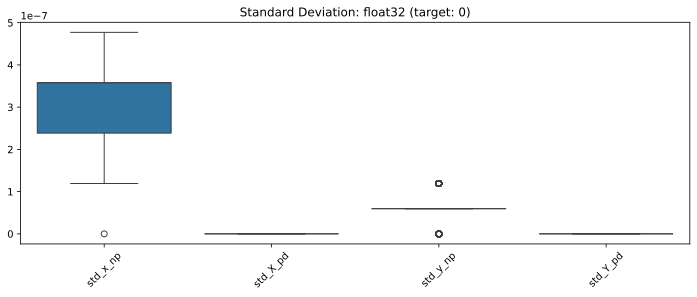

In [35]:
fig,ax = plt.subplots(1,figsize=(12,4))
ax = sns.boxplot(data = results_F32.iloc[:,4:])
ax.tick_params(axis='x', labelrotation=45)
plt.title('Standard Deviation: float32 (target: 0)')
plt.show()

In this float32 sweep, pandas returns a standard deviation of zero for every array size. The plot below therefore shows only the NumPy results.

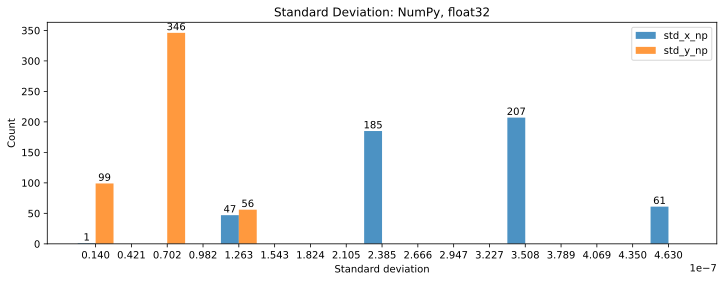

In [36]:
n_bins = 17

x = results_F32['std_x_np'].to_numpy()
y = results_F32['std_y_np'].to_numpy()

Min = min(x.min(), y.min())
Max = max(x.max(), y.max())

edges = np.linspace(Min,Max,n_bins + 1)


hist_x, _ = np.histogram(x, bins=edges)
hist_y, _ = np.histogram(y, bins=edges)

centers = (edges[:-1] + edges[1:]) / 2
width = edges[1] - edges[0]

fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(
    centers - width/4,
    hist_x,
    width=width/2,
    label='std_x_np',
    alpha=0.8
)

ax.bar(
    centers + width/4,
    hist_y,
    width=width/2,
    label='std_y_np',
    alpha=0.8
)

ax.set_title('Standard Deviation: NumPy, float32')
ax.set_xlabel('Standard deviation')
ax.set_ylabel('Count')

ax.set_xticks(centers)
ax.legend()


for i, x_val in enumerate(centers):
        if hist_x[i] > 0:
            ax.text(x_val - width/4, hist_x[i] + 0.5, int(hist_x[i]),
                    ha='center', va='bottom')
            
        if hist_y[i] > 0:
            ax.text(x_val + width/4, hist_y[i] + 0.5, int(hist_y[i]),
                ha='center', va='bottom')

plt.show()

In [37]:
len(np.where(results_F32['std_x_np'] == 0)[0])

1

In [38]:
len(np.where(results_F32['std_y_np'] == 0)[0])

99

The following plot confirms the pandas results are all zero.

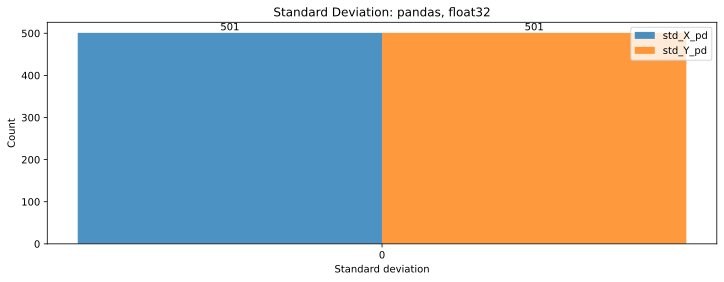

In [39]:
x = results_F32['std_X_pd'].to_numpy()
y = results_F32['std_Y_pd'].to_numpy()

edges = np.histogram_bin_edges(
    np.concatenate([x, y]),
    bins='auto')

hist_x, _ = np.histogram(x, bins=edges)
hist_y, _ = np.histogram(y, bins=edges)

centers = (edges[:-1] + edges[1:]) / 2
width = edges[1] - edges[0]

fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(
    centers - width/4,
    hist_x,
    width=width/2,
    label='std_X_pd',
    alpha=0.8
)

ax.bar(
    centers + width/4,
    hist_y,
    width=width/2,
    label='std_Y_pd',
    alpha=0.8
)

ax.set_title('Standard Deviation: pandas, float32')
ax.set_xlabel('Standard deviation')
ax.set_ylabel('Count')

ax.set_xticks(centers)
ax.legend()


for i, x_val in enumerate(centers):
        if hist_x[i] > 0:
            ax.text(x_val - width/4, hist_x[i] + 0.5, int(hist_x[i]),
                    ha='center', va='bottom')
            
        if hist_y[i] > 0:
            ax.text(x_val + width/4, hist_y[i] + 0.5, int(hist_y[i]),
                ha='center', va='bottom')

plt.show()

All 501 array sizes ($N = 1000$–$1500$) have a pandas standard deviation of zero. This behavior is examined in a separate notebook.

## 3.5 Standard-deviation equality matrices

These matrices show which NumPy and pandas standard-deviation result series are exactly equal.

### 3.5.1 float64

In [40]:
df64 = results_F64.loc[:,['std_x_np','std_X_pd','std_y_np','std_Y_pd']]

In [41]:
equality_matrix_64 = pd.DataFrame([[df64[c1].equals(df64[c2]) for c2 in df64.columns] for c1 in df64.columns],
    index=df64.columns,
    columns=df64.columns
)

print(equality_matrix_64)

          std_x_np  std_X_pd  std_y_np  std_Y_pd
std_x_np      True      True     False     False
std_X_pd      True      True     False     False
std_y_np     False     False      True      True
std_Y_pd     False     False      True      True


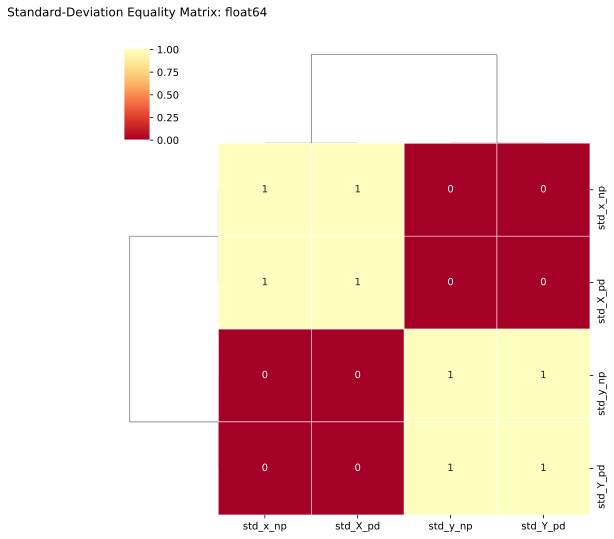

In [42]:
sns.clustermap(
    equality_matrix_64,
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    center = 1,
    annot=True,
    linewidths=.5,
    figsize=(7,7)
)
plt.title('Standard-Deviation Equality Matrix: float64', y=1.3)
plt.show()

For float64, the NumPy and pandas results match for x/X and y/Y, respectively.

### 3.5.2 float32

In [43]:
df32 = results_F32.loc[:,['std_x_np','std_X_pd','std_y_np','std_Y_pd']]

In [44]:
equality_matrix_32 = pd.DataFrame([[df32[c1].equals(df32[c2]) for c2 in df32.columns] for c1 in df32.columns],
    index=df32.columns,
    columns=df32.columns
)

print(equality_matrix_32)

          std_x_np  std_X_pd  std_y_np  std_Y_pd
std_x_np      True     False     False     False
std_X_pd     False      True     False      True
std_y_np     False     False      True     False
std_Y_pd     False      True     False      True


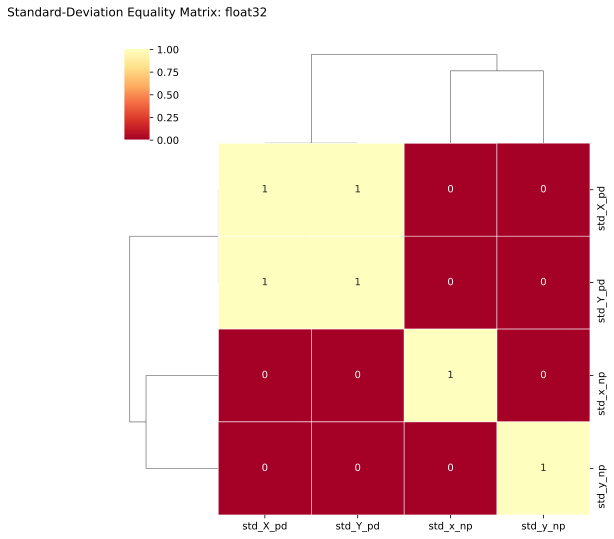

In [45]:
sns.clustermap(
    equality_matrix_32,
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    center = 1,
    annot=True,
    linewidths=.5,
    figsize=(7,7)
)
plt.title('Standard-Deviation Equality Matrix: float32', y=1.3)
plt.show()

For float32, the NumPy and pandas results no longer match their x/X or y/Y counterparts. The pandas results for X and Y do match because both are zero.

# 4. Conclusion

A constant floating-point vector can produce a non-zero computed variance when the reduction used to calculate its mean rounds away from the stored value.

For the float32 inputs in this notebook, pandas native `Series.std()` returns zero while NumPy returns a small non-zero value. That implementation difference is examined in [Part II](02_Floating_point_arithmetic_rounding_error_Part-II.ipynb).

I encountered this behavior while debugging an unexpected correlation result. Only afterwards did I find that related floating-point effects had already been discussed in the NumPy and pandas issue trackers. The examples here focus on reproducing and understanding the numerical mechanism.

# 5. Manual Verification

This final calculation implements the sample standard-deviation formula directly and compares it with the library results.

In [46]:
# Manually calculate the sample standard deviation.
N = 1448

x = np.repeat(1.810, N)
y = np.repeat(0.576, N)

X = pd.Series(x)
Y = pd.Series(y)

xc = x - x.mean()
Xc = X - X.mean()

yc = y - y.mean()
Yc = Y - Y.mean()

std_X_d0 = np.sqrt((Xc**2).sum() / len(Xc))
std_X_d1 = np.sqrt((Xc**2).sum() / (len(Xc)-1))

std_Y_d0 = np.sqrt((Yc**2).sum() / len(Yc))
std_Y_d1 = np.sqrt((Yc**2).sum() / (len(Yc)-1))

std_x_d0 = np.sqrt((xc**2).sum() / len(xc))
std_x_d1 = np.sqrt((xc**2).sum() / (len(xc)-1))

std_y_d0 = np.sqrt((yc**2).sum() / len(yc))
std_y_d1 = np.sqrt((yc**2).sum() / (len(yc)-1))

print('-' * 40)
print(f"Manual pandas standard deviation of X: {std_X_d1}")
print(f"pandas Series.std() agrees for X: {std_X_d1 == X.std(ddof=1)}")
print(f"Manual NumPy standard deviation of x: {std_x_d1}")
print(f"NumPy std() agrees for x: {std_x_d1 == x.std(ddof=1)}")
print('-' * 40)
print(f"Manual pandas standard deviation of Y: {std_Y_d1}")
print(f"pandas Series.std() agrees for Y: {std_Y_d1 == Y.std(ddof=1)}")
print(f"Manual NumPy standard deviation of y: {std_y_d1}")
print(f"NumPy std() agrees for y: {std_y_d1 == y.std(ddof=1)}")
print('-' * 40)


----------------------------------------
Manual pandas standard deviation of X: 2.2212131752187e-16
pandas Series.std() agrees for X: True
Manual NumPy standard deviation of x: 2.2212131752187e-16
NumPy std() agrees for x: True
----------------------------------------
Manual pandas standard deviation of Y: 1.11060658760935e-16
pandas Series.std() agrees for Y: True
Manual NumPy standard deviation of y: 1.11060658760935e-16
NumPy std() agrees for y: True
----------------------------------------
